![1x8 speaker pic](img/speaker_pic_1x8.png)

# How's it sound?

I like it, and have gotten good comments about it from band mates. One of them is a bassist. I'm testing it with my GK MB200 head, which is capable of delivering roughly 100 Watts into 8 Ohms.

When I test it at home, at full power, there's some audible distortion, which may include port noise. This could be partly due to the port pointing towards my ears, whereas the previous port was on the side of the box. But it's a level of distortion that's utterly drowned out by the other instruments in any band setting.

I'm going to tentatively say that the speaker benefits from a high pass filter (HPF), but that the filter can be left at its lowest frequency setting. In my case, that's about 35 Hz.

# Design goals

It was time for a re-build of my 8" bass speaker. I was happy with the sound of my little 8"er, but I want to try a tilt-back cabinet. The project also gives me a chance to re-think my original design choices and see if I still believe them. Without buying a new driver!

In case you've arrived here for the first time, I'm a bassist. My main instrument is double bass, though I play some electric bass too. I'm also a physicist and electronics hobbyist, and have been interested in understanding how music gear works, for almost 50 years. I've been playing through homemade speakers for most of that time, and this is a step in the evolution of my designs.

Since I'm already happy with the tone quality of my speaker, I'm not going to change it much. The curves will tell more. The response curve is not flat, but still has plenty of support down to the lowest fundamental. The low end is noticeable, and I like it. It gives the bass some real tone in slow passages, and doesn't really seem to get in the way of articulation in faster passages or soloing in the higher octaves. Perhaps it "sits in the mix," inasmuch as there's not much else going on in the lowest octave, in the typical small jazz ensemble.

One issue faced by all home builders is power handling. Commercial makers need to offer a "rating" that doesn't make their product seem uncompetitive, but that also doesn't invite destructive use. My job is simpler since I have only one "customer," myself. I design my speakers around the amplifiers that I'm using, and I've measured their performance. And my sonic needs are somewhat limited by the kinds of gigs that I expect to play. For this project, I think a goal of handling 100 Watts is realistic.

I face another odd dilemma: Will my speaker need a high pass filter (HPF)? I sell a HPF, and I always use one even if not needed. It's a good way to get more real-world testing of my designs. On the other hand, I'd feel a little bit guilty about promoting a speaker design that absolutely requires an HPF. For now my rule will be to hope that an HPF is unnecessary, but see how much more performance I can get with one. On the other hand, "accessory-free amplification" can be kind of a compulsion rather than a necessity.

Size and weight will be important. I actually don't have a lot of space, since I have a tiny car, and I often carpool with another band member. And things like efficiency and economy are part of real engineering.

## The economics and practicality of it

Is it worth it, economically? The driver for this design is expensive, about $250 last time I checked. How does the rest of the project work out? Pretty cheap, for a couple of reasons. First of all, I already have all of the tools, from 30+ years of home maintenance. Second, I don't buy a lot of speaker hardware. My use of speakers qualifies as "light duty." I always transport my own gear, and it never gets thrown around by roadies. And it's small. I've decided that I don't need all of the trappings of "professional" gear such as casters, corners, tolex, custom grille, jack plate, handles, etc. That stuff can add a lot to the cost of a project.

## Is it a practical project?

I don't give a lot of precise details, such as cutting dimensions for the parts. And the port is complex because it's bent. If you want to build one of these, I expect you to compute the needed dimensions. Of course a commercial maker would want to nail things down more precisely, but they only have to figure it out once.

## My preferences

**Ported design**. It's a bit more complex than a sealed design, but it gives you almost an entire octave of response "for free." Also, driver makers mostly offer off-the-shelf drivers that are tailored for ported systems. There have been some sealed systems on the market, but I think they depend on custom drivers.

**Full range driver**. There's no midrange or tweeter. The driver manages itself respectably up to about 4 kHz. I don't expect my bass with a pickup to produce much sizzle above that frequency, that isn't immediately swallowed up by the performance space.

## How to read this notebook

This is a *Jupyter Notebook* which is a familiar sight within the scientific world but kind of a weird apparition elsewhere. It's my *digital lab notebook*. Jupyter allows me to mix program code, data, results, and text, all within a single notebook, that can be shared as-is or converted into other electronic formats such as PDF.

People try to use Jupyter notebooks to write research papers and textbooks with some success, but making it pretty and hiding the dirty innards takes effort. And I don't like hiding innards. I want you to see how I think, and correct me if I'm wrong. So instead, I just leave my entire notebook open for anybody to read, critique, and use.

If you don't want to read the code, I forgive you. Just skim past it, and enjoy the text and graphs.

# Let's get started with calculation

This is going to be my actual design notebook, calculations and all. You're watching me design a speaker. As an added adventure, I'm using my own modeling program as well, from the **speakerTheorySympy** notebook.

In [1]:
%load_ext autoreload
%autoreload 2
import pandas as pd
from speakerTheorySympy import *

def multi_curves(system, axs, label):
    excursion_curve(system, axs[0], label = label)
    sensitivity_curve_ported(system, axs[1], label)
    impedance_curve(system, axs[2], label = label)
    airspeed_curve_ported(system, axs[3], label = label)

# pandas set max digits
pd.set_option('display.precision', 3)

# Driver and original box specs

I will start by modeling my original 8" design. I used it for a few years, and was happy with its tone quality.

In [2]:
faital_8pr200_driver = {
    # Parameters taken from driver datasheet
    'Znom': 8.0, # Nominal impedance, Ohms
    #'P_e': 250, # Rated power, Watts, we don't use this.
    'f_s': 58, # Resonant frequency, Hz
    w_s: sp.N(58*2*sp.pi), # Resonant angular frequency, Hz
    R_e: 5.1, # DC resistance, Ohms
    L_e: 0.55*1e-3, # Voice coil inductance, H
    Q_ms: 9.4, # Mechanical Q factor
    Q_es: 0.38, # Electrical Q factor
    V_as: 16.9*1e-3, # Compliance equivalent air volume, m^3
    'X_max': 8.15*1e-3, # Maximum linear excursion, m
    S_d: 209*1e-4, # Diaphragm area, m^2
    # Additional physical constants taken from mother nature
    rho: 1.2, # Air density, kg/m^3
    c: 343, # Speed of sound, m/s
    # System parameters
    'P_in_rms': 100, # Input power, Watts
    R_ref: 1.0, # Reference distance for SPL calculation, m
    P_ref: 20e-6, # Reference sound pressure for SPL calculation, Pa
}

finish_driver_params(faital_8pr200_driver)

fai_box_1 = {
    # My old design
    N_d: 1,
    V_box: 15*1e-3, # Box volume, liters converted to m^3
    f_port: 40, # Port tuning frequency, Hz
    S_port: 5.5*5.5*1e-4, # Port area, cm*cm converted to m^2
    end_correct: 0.732, # Assumption that both port ends are flanged
    'Z_nom': 8,
    'P_in_rms': 100}

fai_system = build_em_params(faital_8pr200_driver, fai_box_1)
fai_system  = build_ported_params(fai_system, fai_box_1[f_port])

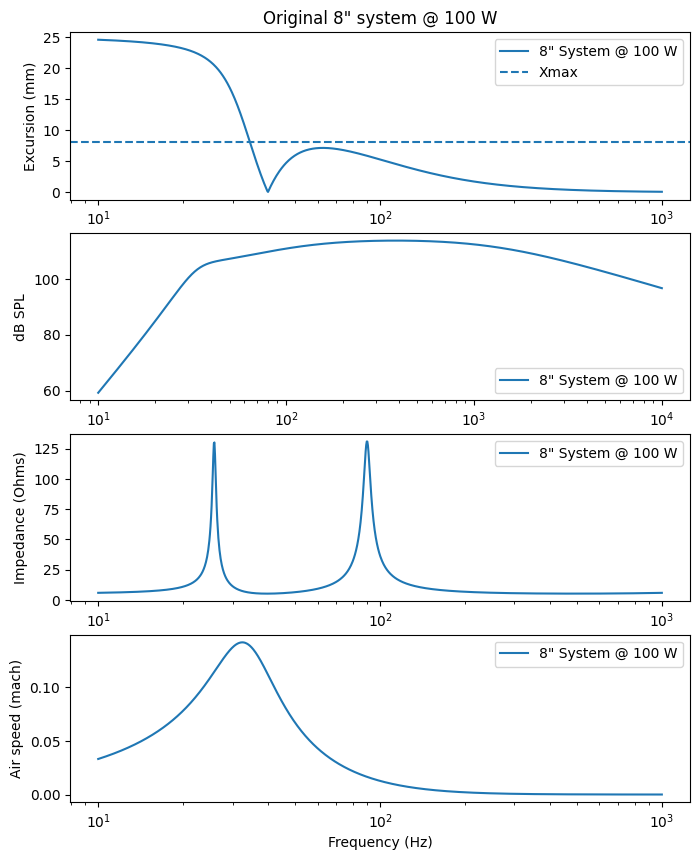

In [3]:
fig, axs = plt.subplots(4, figsize = (8, 10))
multi_curves(fai_system, axs, '8" System @ 100 W')
axs[0].set_title('Original 8" system @ 100 W')
axs[-1].set_xlabel('Frequency (Hz)')
plt.show()

## Critique of original design

**The SPL curve** is for real. This speaker has a solid low end. There's a price to pay for that response, but I like the sound, and I get a lot of compliments for it. If I need more audible volume in louder gigs, I can throttle back on the lowest frequencies with the HPF, and crank my volume up. Or bring a bigger speaker. 

**The excursion curve** is generous at 100 Watts. I don't expect to stress this driver at the power levels that I'm planning for. Higher power levels should be no problem, depending on how bass-heavy your signal is, and you could tame it with an HPF.

**The port air speed curve is worrisome**. This is why I won't "rate" the speaker beyond 100 Watts, and expect to need a steep HPF. The widespread rule of thumb is that max airspeed needs to be kept below 0.1 Mach, i.e., 10% of the speed of sound, to avoid audible turbulence caused by flow of air over the edges of the port mouth.

My build did have some audible port "chuffing," which I was able to pretty much eliminate by generously rounding the edges of the port mouth. Not wanting to shell out for a giant router bit, I rounded the edges with a wood rasp and sandpaper, then cleaned up the rough spots with filler.

# Possible redesign, thinking about the port

My choice of a 40 Hz port tuning is pretty conservative. But a higher tuning could be accompanied by a bigger mouth. Is it possible that there's a better design lurking here? I entered a new design, with a higher port tuning but a bigger port mouth, and played with the numbers until I got roughly the same port length.

One of my habits is "poor man's tolerance analyis," which is to change the box volume by a small amount and see how the curves change. This gives me an idea of just how accurate all of my calculations need to be. I also corrected the port tuning frequency so the ports would have the same dimensions in both cases.

The weird values are because they work out to simple dimensions in inches. I still run a US dimension shop, sorry.

In [4]:
fai_box_2 = {
    # My new design
    N_d: 1,
    V_box: 15*1e-3, # Box volume, liters converted to m^3
    f_port: 50,
    S_port: 5.08*12.7*1e-4, # Port area, cm*cm converted to m^2
    end_correct: 0.732,
    'Z_nom': 8,
    'P_in_rms': 100}

fai_system_2 = build_em_params(faital_8pr200_driver, fai_box_2)
fai_system_2  = build_ported_params(fai_system_2, fai_box_2[f_port])

In [5]:
small_vol = 14
fai_box_3 = {
    # My new design with a slight change in box volume
    N_d: 1,
    V_box: small_vol*1e-3, # Box volume, liters converted to m^3
    f_port: 50*np.sqrt(15/small_vol),
    S_port: 5.08*12.7*1e-4, # Port area, cm*cm converted to m^2
    end_correct: 0.732,
    'Z_nom': 8,
    'P_in_rms': 100}

fai_system_3 = build_em_params(faital_8pr200_driver, fai_box_3)
fai_system_3  = build_ported_params(fai_system_3, fai_box_3[f_port])

In [6]:
fai_box_4 = {
    # My new design, but with the measured port tuning that I ended up with
    N_d: 1,
    V_box: 15*1e-3, # Box volume, liters converted to m^3
    f_port: 46.6,
    S_port: 5.08*12.7*1e-4, # Port area, cm*cm converted to m^2
    end_correct: 0.732,
    'Z_nom': 8,
    'P_in_rms': 100}

fai_system_4 = build_em_params(faital_8pr200_driver, fai_box_4)
fai_system_4  = build_ported_params(fai_system_4, fai_box_4[f_port])

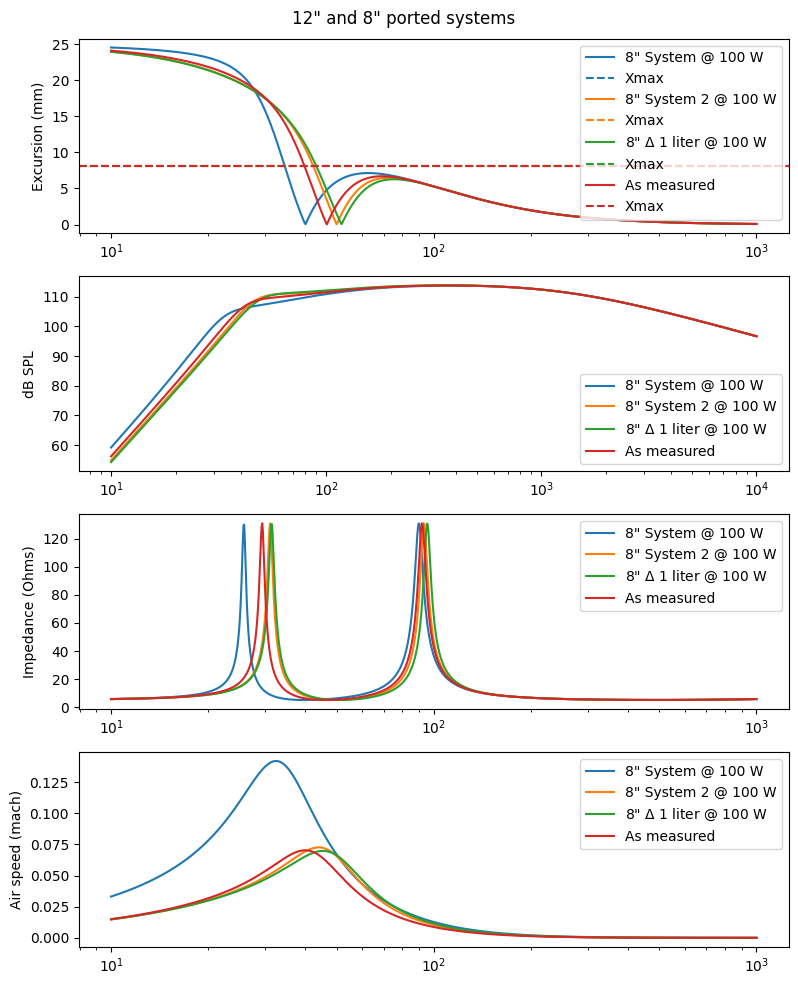

      Parameter    8" System    8" System 2    - 1 liter as measured
0          Znom            8              8            8           8
1           f_s           58             58           58          58
2           w_s          364            364          364         364
3           R_e          5.1            5.1          5.1         5.1
4           L_e      0.00055        0.00055      0.00055     0.00055
5          Q_ms          9.4            9.4          9.4         9.4
6          Q_es         0.38           0.38         0.38        0.38
7          V_as       0.0169         0.0169       0.0169      0.0169
8         X_max      0.00815        0.00815      0.00815     0.00815
9           S_d       0.0209         0.0209       0.0209      0.0209
10          rho          1.2            1.2          1.2         1.2
11            c          343            343          343         343
12     P_in_rms          100            100          100         100
13        R_ref            1      

In [7]:
def multi_curves(system, axs, label):
    excursion_curve(system, axs[0], label = label)
    sensitivity_curve_ported(system, axs[1], label)
    impedance_curve(system, axs[2], label = label)
    airspeed_curve_ported(system, axs[3], label = label)

fig, axs = plt.subplots(4, figsize = (8, 10))
multi_curves(fai_system, axs, '8" System @ 100 W')
multi_curves(fai_system_2, axs, '8" System 2 @ 100 W')
multi_curves(fai_system_3, axs, r'8" $\Delta$ 1 liter @ 100 W')
multi_curves(fai_system_4, axs, 'As measured')

fig.suptitle('12" and 8" ported systems')
fig.tight_layout()
plt.show()

def format_fun(x):
    return f"{x:.3g}"

print(report_table([fai_system, fai_system_2, fai_system_3, fai_system_4], 
                   ['   8" System', '   8" System 2', '   - 1 liter', 'as measured'], 
                   format_fun=format_fun))


## Tentative critique of new design

**The SPL curve** is pretty much the same. I don't think the tiny "hump" at 40 Hz will be an audible difference. 

**The excursion curve** is still OK enough. It only exceeds Xmax below 45 Hz, and this assumes a pure sinewave input.

**The port air speed curve is a lot more generous**. I still plan on flaring the port mouth. The port is a fair amount longer, and will have to be bent inside the box. Thus the assembly process will be more complex.

**I think it's worth trying**. On with the design process.

The box volume used in the modeling program is the *net interior volume* of the box, neglecting the space taken up by the driver and port. The first thing to do is to find the *gross* volume. One thing to note is that a 1 liter change in the net volume barely made a difference to the design.

# Let's build a speaker!

I'm going to get the basic dimensions out of the way, before I switch to pencil and paper for planning my plywood cuts.

In [8]:
fai_system_2[V_box]*1000
#convert liters to cubic inches, sorry
v_box_in3 = fai_system_2[V_box]*1000*61.0237
'net box volume (in^3):', v_box_in3

('net box volume (in^3):', 915.3555)

The volume taken up by the port, neglecting the thickness of the plywood.

In [9]:
lport_in = fai_system_2['L_port_in']
'length of port (in):', lport_in

('length of port (in):', 17.5731444760970)

In [10]:
w_port = 6/2.54
'port width (in):', w_port

('port width (in):', 2.3622047244094486)

In [11]:
t_port_sides = 0.375
v_port_sides = 2*t_port_sides*w_port*lport_in
'volume occupied by port (in^3):', v_port_sides

('volume occupied by port (in^3):', 31.1335236781246)

A guess as to the volume occupied by the driver.

In [12]:
v_driver = 2*61.0237
'volume occupied by driver (in^3):', v_driver

('volume occupied by driver (in^3):', 122.0474)

In [13]:
v_gross = v_box_in3 + v_port_sides + v_driver
'gross volume (in^3):', v_gross

('gross volume (in^3):', 1068.53642367812)

Now I'm going to choose dimensions for the sides of the box, and also choose the size of the triangular portion that's going to make this into a tilt-back speaker. I'm going to make the depth of the panel 1 inch shorter than the height, because there will be a "baffle setback" to protect the driver and grille.

In [14]:
h = 10 # height of side panel
d = h - 1 # depth of side panel
tri = 4 # side of triangle
a_side = h*d - tri**2/2
'area of side panel (in^2):', a_side

('area of side panel (in^2):', 82.0)

In [15]:
w = v_gross/a_side
'width of baffle (in):', w

('width of baffle (in):', 13.0309319960747)

These numbers are the *interior* dimensions of the box, neglecting plywood thickness. Next job is to plan the assembly process. *This is where I get out some ruled paper and start drawing*. But first, I'll preview the assembly process.

*I do not cut all of the parts at once*. The chance of everything fitting together perfectly is zero. And I'm not running a factory. Instead, I cut the pieces one by one and partially assemble the box, measure, and correct the dimensions of the remaining parts if needed. Upright basses are made this way.

Because these are relatively small speakers, I can clamp all of the joints with light duty 36 inch ratcheting furniture clamps. Glue can be whatever you want. I used Titebond.

This is where I get out my grid paper. *Writing and drawing are part of thinking* and the process of drawing my plans helps me check for misconceptions. 

**This is where I stop typing and go into the shop**.

In [16]:
# Code for converting this document to HTML
if __name__ == '__main__':
    if input('OK to save as PDF? (y/n)') == 'y':
        !python3 -m jupyter nbconvert --to pdf "New 8-inch design notes.ipynb"

[NbConvertApp] Converting notebook New 8-inch design notes.ipynb to pdf
[NbConvertApp] Support files will be in New 8-inch design notes_files/
[NbConvertApp] Making directory ./New 8-inch design notes_files
[NbConvertApp] Writing 56121 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 1166255 bytes to New 8-inch design notes.pdf
